# Protein-Class Specific Enrichment Analysis

This notebook computes odds ratios (ORs) for 103 structural and functional protein features comparing pathogenic case variants to benign/population control variants, stratified by PANTHER protein functional class.

**Features (103 total):**

| Category | n |
|---|---|
| Physicochemical property | 46 |
| 3D structural features  | 22 |
| Domain/region annotations | 16 |
| Post-translational modifications | 10 |
| Functional sites | 5 |
| Protein-protein interactions | 4 |

**Input data:**
- Case (pathogenic): `../data/case_annotation.tsv`
- Control (benign + common population): `../data/control_annotation.tsv`

**Output:** Excel spreadsheet with one sheet per metric (OR, CI_lo, CI_up, p_value, q_value); rows = features, columns = protein functional classes

> ⚠️ **Note:** Because HGMD professional data cannot be made public, the case dataset has been redacted. Running this notebook locally may therefore produce OR tables that differ from those reported in the paper.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import false_discovery_control
import os
import warnings
import sys
warnings.filterwarnings('ignore')

In [2]:
sys.path.insert(0, '../src')  # repo source, not an installed older pfes
from pfes.scorer import MAX_ASA, AA_TABLE, SS9_LABELS, RSA_BINS, RSA_LABELS, PLDDT_BINS, PLDDT_LABELS, DIST_BINS, DIST_LABELS, PCHEM_CLASSES, FEATURE_COLS, ATTR_PREFIXES, DISTANCE_MATRIX, DOMAIN_FEATURES, FUNCTION_FEATURES, PTM_FEATURES, bin_values


In [3]:
DATA_DIR   = '../data'
OUTPUT_DIR = '../results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load Data

In [4]:
df_case = pd.read_csv(f'{DATA_DIR}/case_annotation.tsv', sep='\t', low_memory=False)
df_ctrl = pd.read_csv(f'{DATA_DIR}/control_annotation.tsv', sep='\t', low_memory=False)
# The annotation files name this column 'DNA binding region'; the scorer's feature (and g2papi column) is
# 'DNA binding', so the OR table must be labelled 'Function:DNA binding' for the scorer to use it.
df_case = df_case.rename(columns={'DNA binding region': 'DNA binding'})
df_ctrl = df_ctrl.rename(columns={'DNA binding region': 'DNA binding'})
# df_ctrl = pd.read_csv('/media/drive2/seulki/Project/Missense_2025/data/variant-2025Q4/final_control_annotation_score_vep.txt', sep='\t', low_memory=False)
print(f"Case variants  : {len(df_case):>8,}")
print(f"Control variants: {len(df_ctrl):>7,}")
print(f"\nCase columns   : {list(df_case.columns)}")
print(f"\nControl columns: {list(df_ctrl.columns)}")

Case variants  :   87,313
Control variants: 147,188

Case columns   : ['Gene', 'UniProt', 'ResID', 'RefAA', 'AltAA', 'Source', 'Transcript', 'Change_nucleotide', 'protein_class', 'phys_ref', 'AApchem', 'AAdistance', 'ss9', 'plddt', 'asa', 'rsa', 'Active site', 'Binding site', 'Site', 'DNA binding', 'Zinc finger', 'Region', 'Region/Disordered', 'Region/Interaction', 'Region/Others', 'Motif', 'Coiled coil', 'Compositional bias', 'Repeat', 'Domain', 'Topological domain', 'Transmembrane', 'Intramembrane', 'Signal peptide', 'Transit peptide', 'Propeptide', 'Peptide', 'Chain', 'Lipidation', 'Glycosylation', 'Crosslinks', 'Modified residue', 'Acetylation', 'Methylation', 'Phosphorylation', 'SUMOylation', 'Ubiquitination', 'O-GalNAc/GlcNAc', 'HB_intra', 'SB_intra', 'DS_intra', 'NB_intra', 'HB_inter', 'SB_inter', 'DS_inter', 'NB_inter']

Control columns: ['Gene', 'UniProt', 'ResID', 'RefAA', 'AltAA', 'Source', 'Transcript', 'Change_nucleotide', 'protein_class', 'phys_ref', 'AApchem', 'AAdistanc

In [5]:
df_case.protein_class.value_counts()

protein_class
metabolite interconversion enzyme                      15326
not-available                                          12665
transporter                                            12332
extracellular matrix protein                            7180
protein modifying enzyme                                6589
gene-specific transcriptional regulator                 6519
transmembrane signal receptor                           5068
cytoskeletal protein                                    4942
protein-binding activity modulator                      2798
DNA metabolism protein                                  1800
chromatin/chromatin-binding, or -regulatory protein     1710
cell adhesion molecule                                  1420
RNA metabolism protein                                  1357
intercellular signal molecule                           1316
transfer/carrier protein                                1262
scaffold/adaptor protein                                1136
cell junct

## 3. Preprocess

- Standardize `protein_class` strings (spaces → `_`, `/` → `,`)
- Map `not-available` to `unclassified`
- Merge any class with < `MIN_CLASS_SIZE` variants in either case or control into `unclassified`

In [6]:
MIN_CLASS_SIZE = 300

def standardize_protein_class(df):
    df = df.copy()
    df['protein_class'] = (
        df['protein_class']
        .str.replace(' ', '_', regex=False)
        .str.replace('/', ',', regex=False)
    )
    df['protein_class'] = df['protein_class'].replace('not-available', 'unclassified')
    return df

df_case = standardize_protein_class(df_case)
df_ctrl = standardize_protein_class(df_ctrl)

In [7]:
all_classes = (
    set(df_case['protein_class'].unique()) |
    set(df_ctrl['protein_class'].unique())
)
all_classes.discard('unclassified')

valid_classes  = []
merged_classes = []

print(f"{'Protein class':<55} {'Case':>7}  {'Ctrl':>7}  {'Total':>7} Status")
print('-' * 85)

for pc in sorted(all_classes):
    n_case = (df_case['protein_class'] == pc).sum()
    n_ctrl = (df_ctrl['protein_class'] == pc).sum()
    n_total = n_case + n_ctrl
    if n_case >= MIN_CLASS_SIZE and n_ctrl >= MIN_CLASS_SIZE:
        valid_classes.append(pc)
        status = 'keep'
    else:
        merged_classes.append(pc)
        df_case['protein_class'] = df_case['protein_class'].replace(pc, 'unclassified')
        df_ctrl['protein_class'] = df_ctrl['protein_class'].replace(pc, 'unclassified')
        status = f'→ unclassified'
    print(f"  {pc:<53} {n_case:>7,}  {n_ctrl:>7,}  {n_total:>7,} {status}")

valid_classes.append('unclassified')
print(f"\nValid classes ({len(valid_classes)}): {valid_classes}")

Protein class                                              Case     Ctrl    Total Status
-------------------------------------------------------------------------------------
  DNA_metabolism_protein                                  1,800    3,612    5,412 keep
  RNA_metabolism_protein                                  1,357    4,542    5,899 keep
  calcium-binding_protein                                   106      386      492 → unclassified


  cell_adhesion_molecule                                  1,420    4,385    5,805 keep
  cell_junction_protein                                     891      229    1,120 → unclassified
  chaperone                                                 295      747    1,042 → unclassified
  chromatin,chromatin-binding,_or_-regulatory_protein     1,710    4,816    6,526 keep
  cytoskeletal_protein                                    4,942    8,427   13,369 keep
  defense,immunity_protein                                  422    3,001    3,423 keep
  extracellular_matrix_protein                            7,180    4,592   11,772 keep
  gene-specific_transcriptional_regulator                 6,519   10,135   16,654 keep
  intercellular_signal_molecule                           1,316    1,804    3,120 keep
  membrane_traffic_protein                                  704    2,324    3,028 keep
  metabolite_interconversion_enzyme                      15,326   10,523   25,849 keep
  protein-binding_activ

  transfer,carrier_protein                                1,262    1,029    2,291 keep
  translational_protein                                     736    1,033    1,769 keep
  transmembrane_signal_receptor                           5,068    9,012   14,080 keep
  transporter                                            12,332    9,472   21,804 keep
  viral_or_transposable_element_protein                       1      138      139 → unclassified

Valid classes (20): ['DNA_metabolism_protein', 'RNA_metabolism_protein', 'cell_adhesion_molecule', 'chromatin,chromatin-binding,_or_-regulatory_protein', 'cytoskeletal_protein', 'defense,immunity_protein', 'extracellular_matrix_protein', 'gene-specific_transcriptional_regulator', 'intercellular_signal_molecule', 'membrane_traffic_protein', 'metabolite_interconversion_enzyme', 'protein-binding_activity_modulator', 'protein_modifying_enzyme', 'scaffold,adaptor_protein', 'structural_protein', 'transfer,carrier_protein', 'translational_protein', 'trans

In [8]:
# Summary of final class sizes
summary_rows = []
for pc in valid_classes:
    n_case = (df_case['protein_class'] == pc).sum()
    n_ctrl = (df_ctrl['protein_class'] == pc).sum()
    summary_rows.append({'protein_class': pc, 'n_case': n_case, 'n_ctrl': n_ctrl})

df_class_summary = pd.DataFrame(summary_rows).set_index('protein_class')
df_class_summary

,n_case,n_ctrl
protein_class,,
DNA_metabolism_protein,1800,3612
RNA_metabolism_protein,1357,4542
cell_adhesion_molecule,1420,4385
"chromatin,chromatin-binding,_or_-regulatory_protein",1710,4816
cytoskeletal_protein,4942,8427
"defense,immunity_protein",422,3001
extracellular_matrix_protein,7180,4592
gene-specific_transcriptional_regulator,6519,10135
intercellular_signal_molecule,1316,1804


## 4. Feature Definitions

In [9]:
# Feature definitions (SS9_LABELS, RSA_*, PLDDT_*, DIST_*, PCHEM_CLASSES, FUNCTION_FEATURES, DOMAIN_FEATURES,
# PTM_FEATURES) are imported from pfes.scorer so the ORs are estimated on exactly the features the scorer applies
# them to. All bins are [a, b): RSA 0.05 -> Buried, pLDDT 90 -> Very high, Grantham 50 -> Moderate.
SS9_NAMES  = {
    'B': 'Beta bridge', 'E': 'Beta sheet', 'G': '3/10 helix',
    'H': 'Alpha helix', 'I': 'Pi helix',    'P': 'Poly-Pro helix',
    'C': 'Coil',        'S': 'Bend',        'T': 'Turn',
}

# Intra-protein interactions (4)
PI_FEATURES = [ 'HB_intra', 'SB_intra', 'DS_intra', 'NB_intra'] 

# Protein-protein interaction contacts (4)
PPI_FEATURES = [
    'HB_inter', 'SB_inter', 'DS_inter', 'NB_inter',
]

N_FEATURES = (
    len(SS9_LABELS) + len(RSA_LABELS) + len(PLDDT_LABELS) + len(PI_FEATURES) +
    len(PCHEM_CLASSES)**2 + len(PCHEM_CLASSES) + len(DIST_LABELS) +
    len(FUNCTION_FEATURES) + len(DOMAIN_FEATURES) + len(PTM_FEATURES) + len(PPI_FEATURES)
)
assert N_FEATURES == 103, f"Expected 103 features, got {N_FEATURES}"
print(f"Total features: {N_FEATURES}")

Total features: 103


## 5. Statistical Functions

In [10]:
def fisher_test(a, b, c, d):
    """
    Fisher's exact test on a 2x2 contingency table.

    Table layout:
                  feature=yes   feature=no
      case group      a              b
      ctrl group      c              d

    Returns
    -------
    odds : float
        Odds ratio  (a*d) / (b*c)
    p_value : float
        Two-sided p-value from Fisher's exact test
    CI_lo, CI_up : float
        95% confidence interval on the OR (Woolf logit method).
        Haldane-Anscombe correction (+0.5) applied when any cell is 0.
    """
    table = np.array([[a, b], [c, d]], dtype=float)
    odds, p_value = stats.fisher_exact(table)

    # CI via Woolf logit; add 0.5 to all cells if any cell is zero
    t = table + 0.5 if np.any(table == 0) else table
    a_, b_, c_, d_ = t.flatten()
    log_or = np.log((a_ * d_) / (b_ * c_))
    se     = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
    CI_lo  = np.exp(log_or - 1.96 * se)
    CI_up  = np.exp(log_or + 1.96 * se)

    return odds, p_value, CI_lo, CI_up

In [11]:
def is_present(series):
    """True where annotation is present (not NaN and not '-')."""
    return series.notna() & (series != '-')


def compute_or_features(df_case, df_ctrl):
    """
    Compute OR for all 103 features between case and control DataFrames.

    Returns
    -------
    pd.DataFrame  —  index = feature label, columns = OR, CI_lo, CI_up,
                     p_value, q_value, n_case_yes, n_ctrl_yes
    """
    records = {}
    n_case  = len(df_case)
    n_ctrl  = len(df_ctrl)

    def add(name, n_case, n_ctrl, yes_case, yes_ctrl):
        yes_case = int(yes_case)
        yes_ctrl = int(yes_ctrl)
        if n_case == 0 or n_ctrl == 0 or (yes_case == n_case and yes_ctrl == n_ctrl):
            records[name] = dict(
                OR=np.nan, CI_lo=np.nan, CI_up=np.nan,
                p_value=np.nan, n_case_yes=yes_case, n_ctrl_yes=yes_ctrl,
            )
            return
        or_, p, clo, cup = fisher_test(
            yes_case, n_case - yes_case,
            yes_ctrl, n_ctrl - yes_ctrl,
        )
        records[name] = dict(
            OR=or_, CI_lo=clo, CI_up=cup,
            p_value=p, n_case_yes=yes_case, n_ctrl_yes=yes_ctrl,
        )

    # ── 1. Secondary structure (9) ───────────────────────────────────────────
    for val in SS9_LABELS:
        # '-' = no DSSP assignment: not assessable, so excluded from the denominator
        case_ss9 = df_case['ss9'].replace('-', np.nan).dropna()
        ctrl_ss9 = df_ctrl['ss9'].replace('-', np.nan).dropna()
        add(f'SS:{val}',
            len(case_ss9), len(ctrl_ss9),
            (case_ss9 == val).sum(),
            (ctrl_ss9 == val).sum())

    # ── 2. Relative solvent accessibility (5) ────────────────────────────────
    case_rsa = bin_values(df_case['rsa'].dropna(), RSA_BINS, RSA_LABELS)
    ctrl_rsa = bin_values(df_ctrl['rsa'].dropna(), RSA_BINS, RSA_LABELS)
    for val in RSA_LABELS:
        add(f'RSA:{val}', len(case_rsa), len(ctrl_rsa), (case_rsa == val).sum(), (ctrl_rsa == val).sum())

    # ── 3. AlphaFold pLDDT (4) ───────────────────────────────────────────────
    case_plddt = bin_values(df_case['plddt'].dropna(), PLDDT_BINS, PLDDT_LABELS)
    ctrl_plddt = bin_values(df_ctrl['plddt'].dropna(), PLDDT_BINS, PLDDT_LABELS)
    for val in PLDDT_LABELS:
        add(f'pLDDT:{val}', len(case_plddt), len(ctrl_plddt), (case_plddt == val).sum(), (ctrl_plddt == val).sum())

    # ── 4. AA physicochemical change (36) ────────────────────────────────────
    for ref in PCHEM_CLASSES:
        for alt in PCHEM_CLASSES:
            label = f'{ref}>{alt}'
            add(f'AAchange:{label}',
                n_case, n_ctrl,
                (df_case['AApchem'] == label).sum(),
                (df_ctrl['AApchem'] == label).sum())

    # ── 5. Reference AA physicochemical class (6) ────────────────────────────
    for val in PCHEM_CLASSES:
        add(f'RefAA:{val}',
            n_case, n_ctrl,
            (df_case['phys_ref'] == val).sum(),
            (df_ctrl['phys_ref'] == val).sum())

    # ── 6. Grantham distance (4) ─────────────────────────────────────────────
    case_dist = bin_values(df_case['AAdistance'].dropna(), DIST_BINS, DIST_LABELS)
    ctrl_dist = bin_values(df_ctrl['AAdistance'].dropna(), DIST_BINS, DIST_LABELS)
    for val in DIST_LABELS:
        add(f'Grantham:{val}', len(case_dist), len(ctrl_dist), (case_dist == val).sum(), (ctrl_dist == val).sum())

    # ── 7. Intra-protein interactions (4) ────────────────────────────────────
    for feat in PI_FEATURES:
        case_pi = is_present(df_case[feat].dropna())
        ctrl_pi = is_present(df_ctrl[feat].dropna())
        add(f'Intra:{feat}',
            len(case_pi), len(ctrl_pi),
            case_pi.sum(),
            ctrl_pi.sum())

    # ── 8. UniProt functional sites (5) ──────────────────────────────────────
    for feat in FUNCTION_FEATURES:
        case_function = is_present(df_case[feat].dropna())
        ctrl_function = is_present(df_ctrl[feat].dropna())
        add(f'Function:{feat}',
            len(case_function), len(ctrl_function),
            case_function.sum(),
            ctrl_function.sum())

    # ── 9. UniProt domain/region annotations (16) ────────────────────────────
    for feat in DOMAIN_FEATURES:
        case_domain = is_present(df_case[feat].dropna())
        ctrl_domain = is_present(df_ctrl[feat].dropna())
        add(f'Domain:{feat}',
            len(case_domain), len(ctrl_domain),
            case_domain.sum(),
            ctrl_domain.sum())

    # ── 10. Post-translational modifications (10) ────────────────────────────
    for feat in PTM_FEATURES:
        case_ptm = is_present(df_case[feat].dropna())
        ctrl_ptm = is_present(df_ctrl[feat].dropna())
        add(f'Modification:{feat}',
            len(case_ptm), len(ctrl_ptm),
            case_ptm.sum(),
            ctrl_ptm.sum())

    # ── 11. Inter-protein interactions (4) ───────────────────────────────────
    for feat in PPI_FEATURES:
        case_ppi = is_present(df_case[feat].dropna())
        ctrl_ppi = is_present(df_ctrl[feat].dropna())
        add(f'Inter:{feat}',
            len(case_ppi), len(ctrl_ppi),
            case_ppi.sum(),
            ctrl_ppi.sum())

    df = pd.DataFrame(records).T
    df.index.name = 'feature'

    # BH FDR correction across all 103 features
    valid_mask = df['p_value'].notna()
    q_values   = np.full(len(df), np.nan)
    if valid_mask.sum() > 0:
        q_values[valid_mask] = false_discovery_control(
            df.loc[valid_mask, 'p_value'].values, method='bh'
        )
    df.insert(df.columns.get_loc('p_value') + 1, 'q_value', q_values)
    return df

## 6. Compute OR — All Case / Control

In [12]:
print(f"Case: {len(df_case):,} variants  |  Control: {len(df_ctrl):,} variants")
or_all = compute_or_features(df_case, df_ctrl)

n_sig = (or_all['q_value'] < 0.01).sum()
print(f"Features computed : {len(or_all)}")
print(f"Significant (q<0.01): {n_sig}")
or_all.head(15)

Case: 87,313 variants  |  Control: 147,188 variants


Features computed : 103
Significant (q<0.01): 98


,OR,CI_lo,CI_up,p_value,q_value,n_case_yes,n_ctrl_yes
feature,,,,,,,
SS:B,2.112536,1.890452,2.360710,4.191970e-40,6.081308e-40,725.0,552.0
SS:E,1.934464,1.883830,1.986459,0.000000e+00,0.000000e+00,13248.0,11922.0
SS:G,1.374428,1.300937,1.452072,1.758560e-29,2.415089e-29,2420.0,2842.0
SS:H,1.669380,1.637532,1.701847,0.000000e+00,0.000000e+00,28467.0,31872.0
SS:I,3.288912,2.899896,3.730115,7.357646e-83,1.329540e-82,741.0,363.0
SS:P,0.974849,0.933334,1.018210,2.541518e-01,2.591845e-01,3413.0,5598.0
SS:C,0.351045,0.344097,0.358133,0.000000e+00,0.000000e+00,17828.0,57470.0
SS:S,1.311763,1.265392,1.359835,6.684515e-49,1.059239e-48,5726.0,7109.0
SS:T,1.180034,1.142548,1.218750,1.459026e-23,1.902274e-23,6937.0,9537.0


## 7. Compute OR — By Protein Class

In [13]:
or_by_class = {}

print(f"{'Protein class':<55} {'Case':>7}  {'Ctrl':>7}  {'Sig(q<0.05)':>11}")
print('-' * 90)

for pc in valid_classes:
    case_pc = df_case[df_case['protein_class'] == pc]
    ctrl_pc = df_ctrl[df_ctrl['protein_class'] == pc]
    or_pc   = compute_or_features(case_pc, ctrl_pc)
    or_by_class[pc] = or_pc
    n_sig = (or_pc['q_value'] < 0.01).sum()
    print(f"  {pc:<53} {len(case_pc):>7,}  {len(ctrl_pc):>7,}  {n_sig:>11}")

print(f"\nDone. {len(or_by_class)} protein classes computed.")

Protein class                                              Case     Ctrl  Sig(q<0.05)
------------------------------------------------------------------------------------------
  DNA_metabolism_protein                                  1,800    3,612           52


  RNA_metabolism_protein                                  1,357    4,542           55
  cell_adhesion_molecule                                  1,420    4,385           56


  chromatin,chromatin-binding,_or_-regulatory_protein     1,710    4,816           63


  cytoskeletal_protein                                    4,942    8,427           76
  defense,immunity_protein                                  422    3,001           36


  extracellular_matrix_protein                            7,180    4,592           74


...

  structural_protein                                        736    1,308           50
  transfer,carrier_protein                                1,262    1,029           57


  translational_protein                                     736    1,033           35


  transmembrane_signal_receptor                           5,068    9,012           67


  transporter                                            12,332    9,472           73


  unclassified                                           13,960   44,743           89

Done. 20 protein classes computed.


## 8. Combine Results into Spreadsheets

In [14]:
METRICS       = ['OR', 'p_value', 'q_value', 'n_case_yes', 'n_ctrl_yes']
GROUPS        = ['All'] + valid_classes
feature_index = or_all.index

# One DataFrame per metric: rows = features, columns = [All, PC1, PC2, ...]
result_dfs = {}
for metric in METRICS:
    df_m = pd.DataFrame(index=feature_index)
    df_m['All'] = or_all[metric]
    for pc in valid_classes:
        df_m[pc] = or_by_class[pc][metric]
    result_dfs[metric] = df_m

print("OR table (first 10 features, first 5 columns):")
result_dfs['OR'].iloc[:15, :50].round(3)

OR table (first 10 features, first 5 columns):


,All,DNA_metabolism_protein,RNA_metabolism_protein,cell_adhesion_molecule,"chromatin,chromatin-binding,_or_-regulatory_protein",cytoskeletal_protein,"defense,immunity_protein",extracellular_matrix_protein,gene-specific_transcriptional_regulator,intercellular_signal_molecule,...,metabolite_interconversion_enzyme,protein-binding_activity_modulator,protein_modifying_enzyme,"scaffold,adaptor_protein",structural_protein,"transfer,carrier_protein",translational_protein,transmembrane_signal_receptor,transporter,unclassified
feature,,,,,,,,,,,,,,,,,,,,,
SS:B,2.113,1.338,3.109,1.050,1.146,1.774,10.835,0.476,2.556,1.118,...,1.656,1.086,2.347,3.989,15.854,1.039,0.600,4.175,1.385,2.368
SS:E,1.934,2.385,3.267,0.840,6.102,1.928,1.053,0.390,4.130,2.700,...,1.873,2.276,2.340,1.836,3.878,1.761,1.834,2.109,1.152,2.579
SS:G,1.374,0.934,1.519,1.374,3.107,1.755,1.029,0.094,2.697,0.652,...,0.852,0.974,1.574,1.515,1.192,2.146,1.310,1.699,1.552,1.383
SS:H,1.669,1.866,1.707,0.974,3.250,2.026,1.179,0.150,4.619,0.674,...,0.884,1.621,1.470,1.981,1.581,0.672,1.146,0.807,2.242,1.643
SS:I,3.289,1.305,2.221,0.655,3.157,22.927,0.000,0.000,9.887,1.320,...,1.342,1.220,4.915,3.876,0.000,8.411,1.406,0.971,3.225,5.002
SS:P,0.975,0.602,0.783,1.107,0.929,0.407,1.143,3.135,1.019,1.116,...,0.402,0.313,0.612,0.730,0.460,0.848,0.318,1.035,0.439,0.930
SS:C,0.351,0.294,0.315,0.724,0.169,0.226,0.558,1.570,0.161,0.563,...,0.736,0.364,0.351,0.314,0.235,0.584,0.656,0.622,0.244,0.317
SS:S,1.312,1.539,1.725,1.923,2.321,1.392,1.310,0.180,1.229,1.345,...,1.237,1.270,1.341,1.679,0.680,1.998,1.146,1.082,1.159,1.577
SS:T,1.180,1.169,1.450,1.258,2.854,1.641,1.065,0.092,1.331,0.647,...,0.994,1.552,1.151,1.036,1.595,1.068,0.813,1.028,1.171,1.315


## 9. Save Results

## Excel sheets for each metric

In [15]:
xlsx_path = f'{OUTPUT_DIR}/enrichment_OR_by_protein_class.xlsx'

with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    # Metadata sheet
    meta = pd.DataFrame({
        'key': ['n_case_total', 'n_ctrl_total', 'n_features',
                'n_protein_classes', 'min_class_size', 'fdr_method'],
        'value': [len(df_case), len(df_ctrl), N_FEATURES,
                  len(valid_classes), MIN_CLASS_SIZE, 'Benjamini-Hochberg'],
    })
    meta.to_excel(writer, sheet_name='metadata', index=False)

    # Class size sheet
    df_class_summary.to_excel(writer, sheet_name='class_sizes')

    # One sheet per metric
    for metric, df_m in result_dfs.items():
        df_m.to_excel(writer, sheet_name=metric)

print(f"Saved: {xlsx_path}")
print(f"Sheets: metadata, class_sizes, {', '.join(METRICS)}")

Saved: ../results/enrichment_OR_by_protein_class.xlsx
Sheets: metadata, class_sizes, OR, p_value, q_value, n_case_yes, n_ctrl_yes


## Flat CSV with multi-level columns (feature, group, metric)

In [16]:
frames = []
for metric, df_m in result_dfs.items():
    df_m_mi = df_m.copy()
    df_m_mi.columns = pd.MultiIndex.from_tuples(
        [(col, metric) for col in df_m.columns]
    )
    frames.append(df_m_mi)

df_combined = pd.concat(frames, axis=1)
# Reorder columns: group-major, metric-minor
cols_ordered = [
    (grp, metric)
    for grp in GROUPS
    for metric in METRICS
]
df_combined = df_combined[cols_ordered]

# replace group names in the multi-index columns with [x.replace("_"," ").replace(",","/") for x in GROUPS]
new_groups = [x.replace("_", " ").replace(",", "/") for x in GROUPS]
new_columns = []
for col in df_combined.columns:
    group, metric = col
    new_group = group.replace("_", " ").replace(",", "/")
    new_columns.append((new_group, metric))
df_combined.columns = pd.MultiIndex.from_tuples(new_columns)
print("Updated column groups:")
print(df_combined.columns.get_level_values(0).unique())

csv_path = f'{OUTPUT_DIR}/enrichment_OR_by_protein_class.csv'
df_combined.to_csv(csv_path)
print(f"Saved: {csv_path}")
print(f"Shape: {df_combined.shape}  ({df_combined.shape[0]} features × {df_combined.shape[1]} columns)")

Updated column groups:
Index(['All', 'DNA metabolism protein', 'RNA metabolism protein',
       'cell adhesion molecule',
       'chromatin/chromatin-binding/ or -regulatory protein',
       'cytoskeletal protein', 'defense/immunity protein',
       'extracellular matrix protein',
       'gene-specific transcriptional regulator',
       'intercellular signal molecule', 'membrane traffic protein',
       'metabolite interconversion enzyme',
       'protein-binding activity modulator', 'protein modifying enzyme',
       'scaffold/adaptor protein', 'structural protein',
       'transfer/carrier protein', 'translational protein',
       'transmembrane signal receptor', 'transporter', 'unclassified'],
      dtype='object')
Saved: ../results/enrichment_OR_by_protein_class.csv
Shape: (103, 105)  (103 features × 105 columns)


## 10. Heatmap Visualization

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

plt.rcParams['figure.dpi']        = 300
plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.size']         = 7
plt.rcParams['axes.titlesize']    = 7
plt.rcParams['axes.labelsize']    = 7
plt.rcParams['xtick.labelsize']   = 6
plt.rcParams['ytick.labelsize']   = 6
plt.rcParams['legend.fontsize']   = 6
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['axes.linewidth']    = 0.4
plt.rcParams['xtick.major.width'] = 0.4
plt.rcParams['ytick.major.width'] = 0.4
plt.rcParams['xtick.major.size']  = 2.5
plt.rcParams['ytick.major.size']  = 2.5
plt.rcParams['patch.linewidth']   = 0.4

In [18]:
def replace_inf_with_row_max(row):
    """Replace np.inf with the row's finite maximum."""
    max_val = row.replace([np.inf, -np.inf], np.nan).max()
    return row.replace(np.inf, max_val)


def change_feature_name(feature_list):
    """Map prefixed feature labels to publication-ready display names."""
    _map = {
        # Secondary structure
        'SS:B': '$\\beta$-bridge',     'SS:E': '$\\beta$-sheet',
        'SS:G': '3$_{10}$-helix',      'SS:H': '$\\alpha$-helix',
        'SS:I': '$\\pi$-helix',        'SS:P': 'Poly-Pro helix',
        'SS:C': 'Loop/Coil',           'SS:S': 'Bend',
        'SS:T': 'Turn',
        # RSA
        'RSA:Core':           'Core',
        'RSA:Buried':         'Buried',
        'RSA:Medium-buried':  'Med-buried',
        'RSA:Medium-exposed': 'Med-exposed',
        'RSA:Exposed':        'Exposed',
        # pLDDT
        'pLDDT:Very low':  'pLDDT very low',
        'pLDDT:Low':       'pLDDT low',
        'pLDDT:High':      'pLDDT high',
        'pLDDT:Very high': 'pLDDT very high',
        # Grantham
        'Grantham:Mild':         'Grantham mild',
        'Grantham:Moderate':     'Grantham moderate',
        'Grantham:Substantial':  'Grantham substantial',
        'Grantham:Severe':       'Grantham severe',
        # Intra-protein interactions
        'Intra:HB_intra': 'H-bond (intra)',
        'Intra:SB_intra': 'Salt bridge (intra)',
        'Intra:DS_intra': 'Disulfide (intra)',
        'Intra:NB_intra': 'vdW (intra)',
        # Inter-protein interactions
        'Inter:HB_inter': 'H-bond (inter)',
        'Inter:SB_inter': 'Salt bridge (inter)',
        'Inter:DS_inter': 'Disulfide (inter)',
        'Inter:NB_inter': 'vdW (inter)',
    }
    # For prefixed features not in map, strip the prefix
    def _label(f):
        if f in _map:
            return _map[f]
        if ':' in f:
            return f.split(':', 1)[1]
        return f

    return [_label(f) for f in feature_list]

In [19]:
FDR_THRESHOLD = 0.01

# Mask non-significant ORs with NaN, replace inf with row max
df_OR  = result_dfs['OR']
df_Q   = result_dfs['q_value']
df_OR_masked = df_OR.where(df_Q < FDR_THRESHOLD)
df_OR_masked = df_OR_masked.apply(replace_inf_with_row_max, axis=1)

print(f"OR matrix shape: {df_OR_masked.shape}")
print(f"Non-NaN entries : {df_OR_masked.notna().sum().sum()} / {df_OR_masked.size}")

# Feature groups for per-panel plots
FEAT_GROUPS = {
    'Physchem':    [f for f in df_OR_masked.index if f.startswith(('AAchange:', 'RefAA:', 'Grantham:'))],
    'Structure':    [f for f in df_OR_masked.index if f.startswith(('SS:', 'RSA:', 'pLDDT:', "Intra:"))],
    'Function': [f for f in df_OR_masked.index if f.startswith(('Function:'))],
    'Domain':   [f for f in df_OR_masked.index if f.startswith(('Domain:'))],
    'Modification':   [f for f in df_OR_masked.index if f.startswith(('Modification:'))],
    'PPI':   [f for f in df_OR_masked.index if f.startswith(('Inter:'))],
}
for g, feats in FEAT_GROUPS.items():
    print(f"  {g}: {len(feats)} features")

OR matrix shape: (103, 21)
Non-NaN entries : 1335 / 2163
  Physchem: 46 features
  Structure: 22 features
  Function: 5 features
  Domain: 16 features
  Modification: 10 features
  PPI: 4 features


In [20]:
def plot_heatmap(df_plot, figsize, title='', annotate=False, cmap='coolwarm',
                 vmin=0.05, vmax=20, save_path=None):
    """
    Heatmap of odds ratios.
    Rows (x-axis) = features, Columns (y-axis) = protein classes / All.
    NaN cells (non-significant) are shown in light grey.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Grey background for NaN (non-significant) cells
    ax.set_facecolor('#e0e0e0')

    sns.heatmap(
        df_plot.T,
        ax=ax,
        cmap=cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax),
        cbar=True,
        cbar_kws={'shrink': 0.8, 'pad': 0.02, 'label': 'Odds ratio'},
        annot=annotate,
        fmt='.2f',
        annot_kws={'fontsize': 5},
        linewidths=0,
        linecolor='none',
    )

    ax.set_xticklabels(change_feature_name(list(df_plot.index)), rotation=90, ha='center')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel('')
    ax.set_ylabel('')
    if title:
        ax.set_title(title, pad=4)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.4)

    ax.grid(axis='x', linestyle='--', color='black', linewidth=0.1)
    ax.grid(axis='y', linestyle='--', color='black', linewidth=0.1)

    plt.tight_layout()
    # Fix the margin
    plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

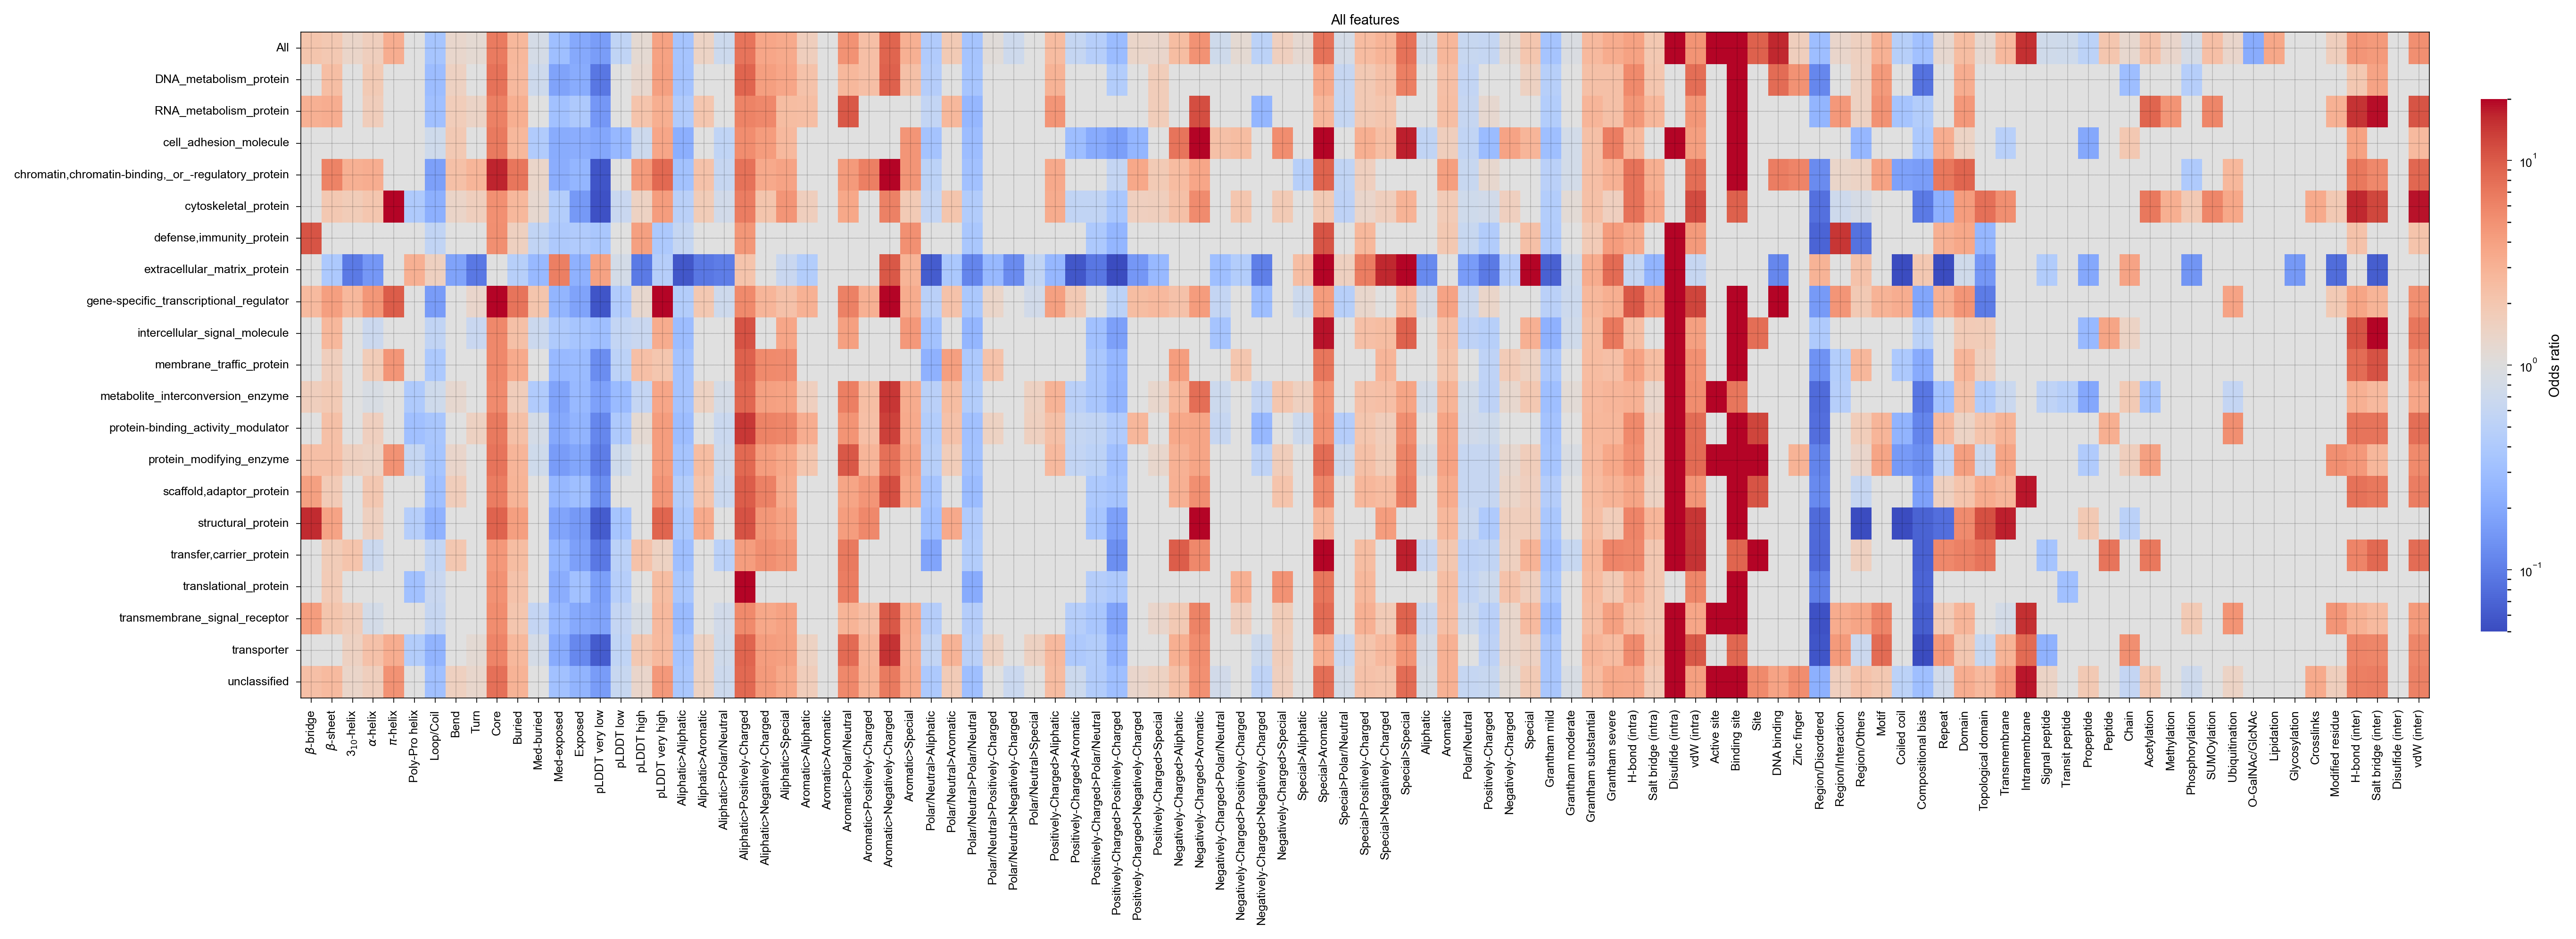

In [21]:
#  Combined heatmap (all 103 features) 
n_classes = len(valid_classes) + 1   # +1 for 'All' column
plot_heatmap(
    df_OR_masked,
    figsize=(103 * 0.22, n_classes * 0.28),
    title='All features',
    annotate=False#,
    # save_path=f'{OUTPUT_DIR}/heatmap_all_features.pdf',
)